In [2]:
import numpy as np

# Electricity price curve (€/kWh) 
# Cheap at night, expensive at peak evening hours 
price_curve = np.array([
    0.08, 0.07, 0.07, 0.07, 0.08, 0.10,  # 00-05h night
    0.14, 0.18, 0.20, 0.19, 0.18, 0.17,  # 06-11h morning ramp
    0.16, 0.16, 0.17, 0.18, 0.21, 0.28,  # 12-17h day
    0.28, 0.25, 0.20, 0.16, 0.12, 0.09   # 18-23h evening
])

# Carbon intensity curve (gCO2/kWh) - German grid mix
# Low at night, dips midday, peaks evening 
carbon_curve = np.array([
    300, 280, 270, 265, 270, 290,  # 00-05h night
    340, 390, 410, 380, 340, 300,  # 06-11h morning ramp
    270, 260, 270, 300, 370, 430,  # 12-17h midday solar dip then rise
    450, 440, 410, 370, 330, 310   # 18-23h evening peak then drop
])

# Demand curve (kWh/hour)
# Low at night, morning spike, evening spike
demand_curve = np.array([
    0.5, 0.4, 0.4, 0.4, 0.5, 0.7,   # 00-05h night
    1.2, 1.4, 1.5, 1.3, 1.2, 1.1,   # 06-11h morning
    1.0, 1.0, 1.1, 1.2, 1.5, 1.8,   # 12-17h day
    1.9, 1.7, 1.4, 1.1, 0.8, 0.6    # 18-23h evening
])


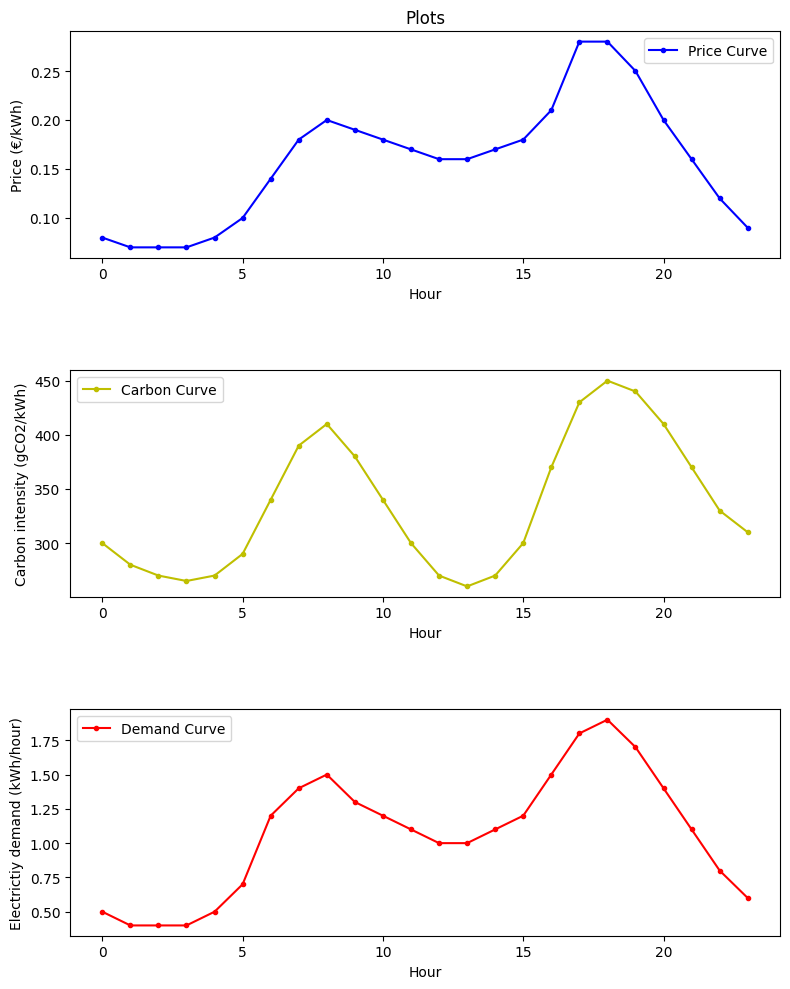

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

x = np.arange(0, 24)

# Define there should be subplots, how many, and orientation
plt.figure(figsize=(8, 10)) 
plt.subplot(3, 1, 1)

# Notice how different colors and markers can be specified in the plot function.
plt.plot(x, price_curve, "b.-",label="Price Curve")
plt.title('Plots')
plt.xlabel("Hour")
plt.ylabel("Price (€/kWh)")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(x, carbon_curve, 'y.-',label="Carbon Curve")
plt.xlabel("Hour")
plt.ylabel("Carbon intensity (gCO2/kWh)")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(x, demand_curve, 'r.-',label="Demand Curve")
plt.xlabel("Hour")
plt.ylabel("Electrictiy demand (kWh/hour)")
plt.legend()

plt.tight_layout(h_pad=5)
plt.show()


In [36]:
# Energy Environment

weight=0.0001

class EnergyEnv:
    def __init__(self):
        self.hour = 0
        self.battery = 5
        self.battery_max = 10
    
    def get_electricity_cost(self):
        electricity_cost = demand_curve[self.hour] * price_curve[self.hour]
        return electricity_cost
       
    def get_reward(self,surcharge=1.0):  # -(electricity costs + carbon penalty)
        electricity_cost = self.get_electricity_cost() * surcharge
        reward = -(electricity_cost + (demand_curve[self.hour] * carbon_curve[self.hour] * weight))
        return reward

    def step(self,action):
        if action == 0:
            # draw from grid
            reward=self.get_reward()
        
        elif action == 1:
            if self.battery>0:
                self.battery-=1
                reward=self.get_reward()
            else:
                reward=self.get_reward(surcharge=1.2)
        
        elif action == 2:
            comfort_penalty = demand_curve[self.hour] * price_curve[self.hour] * 0.5 
            reward=-comfort_penalty

        self.hour += 1
        done = self.hour >= 24
        return (self.hour, self.battery), reward, done
            
    def get_state(self):
        return (self.hour,self.battery)
    
    def reset(self):
        self.hour = 0
        self.battery = 5
        return (self.hour,self.battery) # return to starting state


In [37]:
# Intialize Q-table with zeros
# Hours, battery levels, actions
Q=np.zeros((24,11,3))

In [59]:
# Hyperparamters
alpha=0.1
gamma=0.95
epsilon=1.0
num_episodes=10000
max_steps=24

In [60]:
def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(3)
    else:
        hour, battery = state
        return np.argmax(Q[hour, battery])

In [61]:
def update_q_table(state, action, reward, next_state, done):
    hour, battery = state
    next_hour, next_battery = next_state
    if done:
        td_target = reward
    else:
        td_target = reward + gamma * np.max(Q[next_hour, next_battery])
    td_error = td_target - Q[hour, battery, action]
    Q[hour, battery, action] += alpha * td_error


In [62]:
rewards_per_episode = []

for episode in range(num_episodes):
    state = env.reset()
    total_reward = 0
    for step in range(max_steps):
        action = choose_action(state, epsilon)
        next_state, reward, done = env.step(action)
        update_q_table(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            break
    rewards_per_episode.append(total_reward)
    epsilon = max(0.01, epsilon * 0.995)





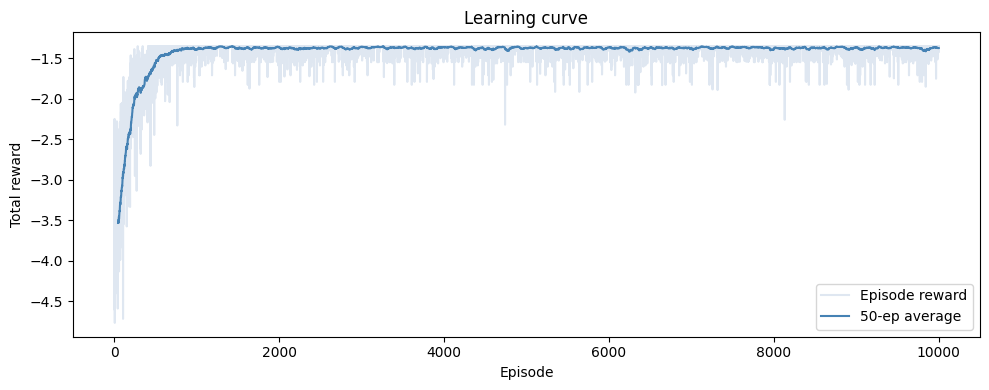

In [68]:
window = 50
smoothed = np.convolve(rewards_per_episode, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(rewards_per_episode, color='lightsteelblue', alpha=0.4, label='Episode reward')
plt.plot(range(window - 1, len(rewards_per_episode)), smoothed, color='steelblue', label=f'{window}-ep average')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.title('Learning curve')
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
battery_level = 5
policy = [np.argmax(Q[h, battery_level]) for h in range(24)]
action_names = ['Grid', 'Battery', 'Shed']
print([action_names[a] for a in policy])

['Shed', 'Shed', 'Shed', 'Shed', 'Shed', 'Shed', 'Shed', 'Battery', 'Battery', 'Shed', 'Shed', 'Shed', 'Shed', 'Shed', 'Shed', 'Battery', 'Battery', 'Battery', 'Battery', 'Battery', 'Battery', 'Battery', 'Battery', 'Battery']


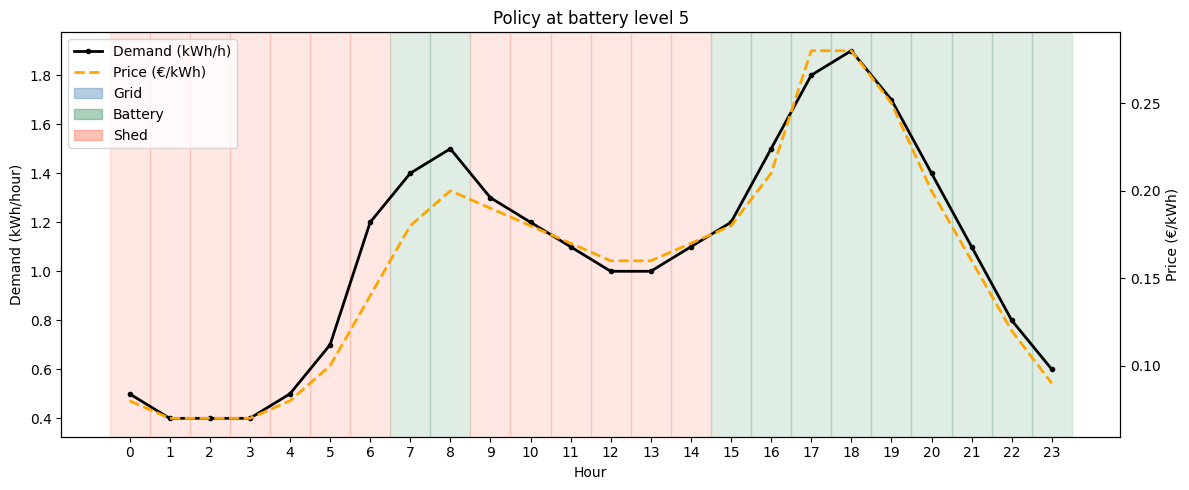

In [70]:
from matplotlib.patches import Patch

hours = np.arange(24)
action_colors = {0: 'steelblue', 1: 'seagreen', 2: 'tomato'}
action_labels = {0: 'Grid', 1: 'Battery', 2: 'Shed'}

fig, ax1 = plt.subplots(figsize=(12, 5))

for h, a in enumerate(policy):
    ax1.axvspan(h - 0.5, h + 0.5, color=action_colors[a], alpha=0.15)

ax1.plot(hours, demand_curve, 'k.-', linewidth=2, label='Demand (kWh/h)')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Demand (kWh/hour)')
ax1.set_xticks(hours)

ax2 = ax1.twinx()
ax2.plot(hours, price_curve, color='orange', linestyle='--', linewidth=2, label='Price (€/kWh)')
ax2.set_ylabel('Price (€/kWh)')

action_patches = [Patch(color=action_colors[a], alpha=0.4, label=action_labels[a]) for a in action_colors]
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles=lines1 + lines2 + action_patches, loc='upper left')

plt.title(f'Policy at battery level {battery_level}')
plt.tight_layout()
plt.show()